In [93]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from pathlib import Path

## Load Data

In [60]:
df = pd.read_csv("../data/cilantro_stats.csv")
print(df.head())

           filename  day  group bagged fridge_layer   mean_hue   std_hue  \
0  Day0_Group_1.jpg    0      1     no          OOF  41.380873  4.856289   
1  Day0_Group_2.jpg    0      2    yes          OOF  41.975349  5.260987   
2  Day0_Group_3.jpg    0      3     no          top  39.752399  3.304823   
3  Day0_Group_4.jpg    0      4    yes          top  42.073473  3.791370   
4  Day0_Group_5.jpg    0      5     no       middle  39.129134  2.898879   

   mean_saturation  std_saturation  mean_value  std_value  mean_blue  \
0       165.978723       62.688090   77.004137  30.792608  33.078127   
1       153.135314       57.238455   79.660080  32.281949  37.821227   
2       164.311842       55.142673   86.248596  28.257065  35.649835   
3       152.930661       51.464017   82.879149  29.562210  37.925593   
4       174.382480       57.410358   74.565063  29.112176  29.229251   

   mean_green   mean_red  
0   77.004137  61.236307  
1   79.660080  63.925379  
2   86.248596  70.430084  
3 

In [77]:
df['group'] = pd.to_numeric(df['group'])

# 1. Create the mapping dictionaries based on your rules
location_map = {
    1: 'out of fridge',
    2: 'out of fridge',
    3: 'layer 1',
    4: 'layer 1',
    5: 'layer 2',
    6: 'layer 2',
    7: 'layer 3',
    8: 'layer 3'
}

bag_map = {
    1: 'out of bag',
    2: 'in bag',
    3: 'out of bag',
    4: 'in bag',
    5: 'out of bag',
    6: 'in bag',
    7: 'out of bag',
    8: 'in bag'
}

# 2. Use the .map() function to create the new columns
df['Location'] = df['group'].map(location_map)
df['Bag'] = df['group'].map(bag_map)

print(df.head())

           filename  day  group bagged fridge_layer   mean_hue   std_hue  \
0  Day0_Group_1.jpg    0      1     no          OOF  41.380873  4.856289   
1  Day0_Group_2.jpg    0      2    yes          OOF  41.975349  5.260987   
2  Day0_Group_3.jpg    0      3     no          top  39.752399  3.304823   
3  Day0_Group_4.jpg    0      4    yes          top  42.073473  3.791370   
4  Day0_Group_5.jpg    0      5     no       middle  39.129134  2.898879   

   mean_saturation  std_saturation  mean_value  std_value  mean_blue  \
0       165.978723       62.688090   77.004137  30.792608  33.078127   
1       153.135314       57.238455   79.660080  32.281949  37.821227   
2       164.311842       55.142673   86.248596  28.257065  35.649835   
3       152.930661       51.464017   82.879149  29.562210  37.925593   
4       174.382480       57.410358   74.565063  29.112176  29.229251   

   mean_green   mean_red       Location         Bag           group_label  
0   77.004137  61.236307  out of f

## EDA


Generating heatmaps:
   group  day  avg_mean_saturation  avg_mean_hue   avg_mean
0      1    0           165.978723     41.380873  77.004137
1      1    1           154.123404     41.486472  69.282625
2      1    2           150.811247     41.407182  64.747758
3      1    3           132.422277     41.249964  63.406785
4      1    4           101.262125     43.334040  61.578535


Text(120.72222222222221, 0.5, 'Experimental Group')

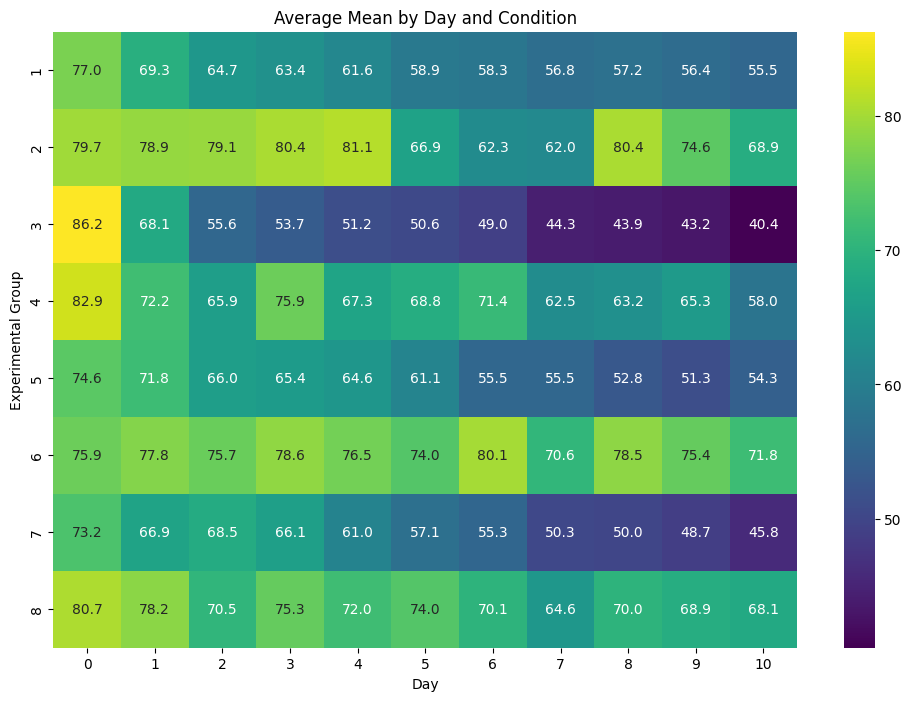

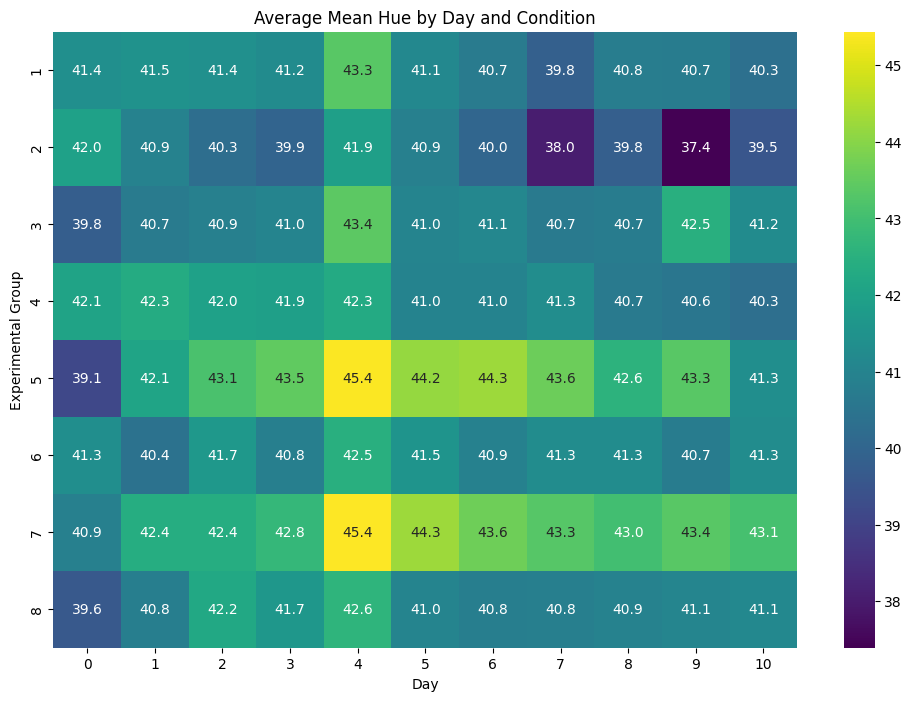

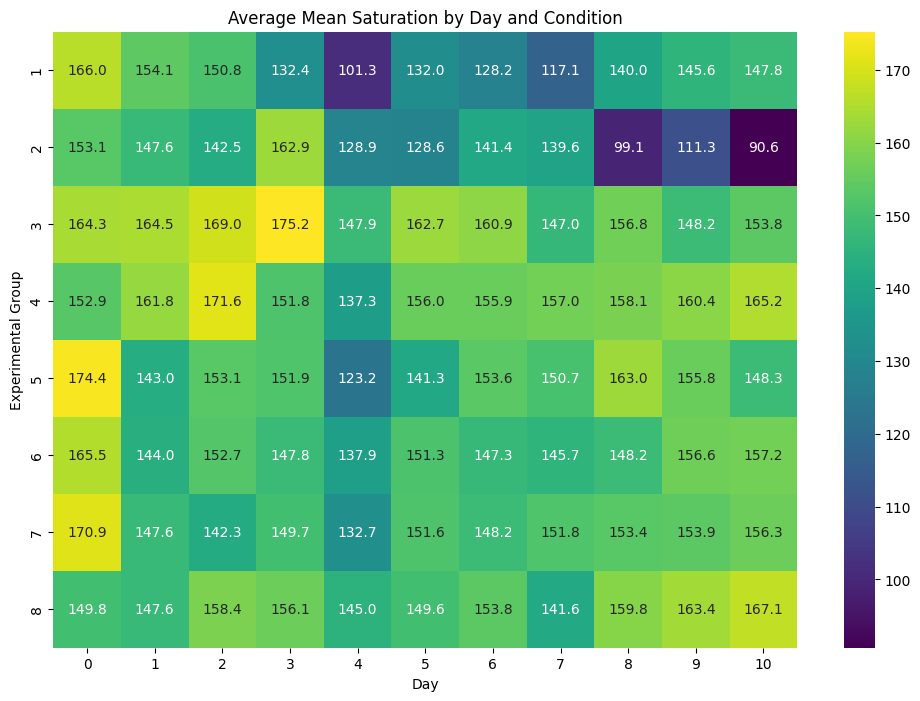

In [96]:
# --- Heatmap Generation ---
print("\nGenerating heatmaps:")

# Aggregate the data for the heatmaps
heatmap_data = df.groupby(['group', 'day']).agg(
    avg_mean_saturation=('mean_saturation', 'mean'),
    avg_mean_hue=('mean_hue', 'mean'),
    avg_mean = ('mean_value', 'mean')
    ).reset_index()

print(heatmap_data.head(5))

#draw the heatma: Rows = group, Columns = day, Values = saturation
heatmap_mean = heatmap_data.pivot(
    index='group', 
    columns='day', 
    values='avg_mean'
)

heatmap_hue = heatmap_data.pivot(
    index='group', 
    columns='day', 
    values='avg_mean_hue'
)

heatmap_sat = heatmap_data.pivot(
    index='group', 
    columns='day', 
    values='avg_mean_saturation'
)
# Plot the heatmap
plt.figure(figsize=(12, 8)) # Set the size of the figure
ax = sns.heatmap(
    heatmap_mean, 
    annot=True,     # Write the data value in each cell
    fmt=".1f",      # Format numbers to one decimal place
    cmap="viridis"  # A common color map (green-to-yellow)
)
plt.title("Average Mean by Day and Condition")
plt.xlabel("Day")
plt.ylabel("Experimental Group")


# Plot the heatmap
plt.figure(figsize=(12, 8)) # Set the size of the figure
ax = sns.heatmap(
    heatmap_hue, 
    annot=True,     # Write the data value in each cell
    fmt=".1f",      # Format numbers to one decimal place
    cmap="viridis"  # A common color map (green-to-yellow)
)
plt.title("Average Mean Hue by Day and Condition")
plt.xlabel("Day")
plt.ylabel("Experimental Group")

# Plot the heatmap
plt.figure(figsize=(12, 8)) # Set the size of the figure
ax = sns.heatmap(
    heatmap_sat, 
    annot=True,     # Write the data value in each cell
    fmt=".1f",      # Format numbers to one decimal place
    cmap="viridis"  # A common color map (green-to-yellow)
)
plt.title("Average Mean Saturation by Day and Condition")
plt.xlabel("Day")
plt.ylabel("Experimental Group")

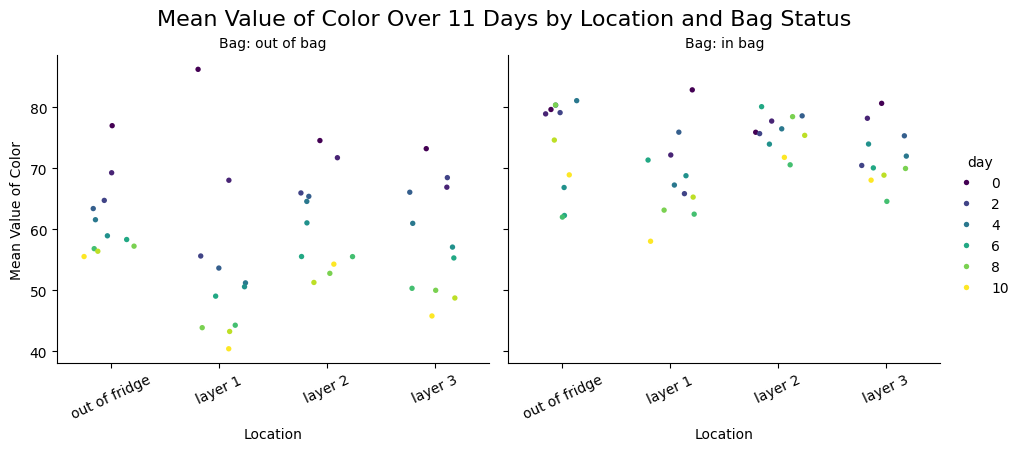

In [102]:
bag_order = ['out of bag', 'in bag']
location_order = ['out of fridge', 'layer 1', 'layer 2', 'layer 3']

g = sns.catplot(
        data=df,
        kind='strip',          # Use 'strip' to plot all 11 points
        x='Location',          # The 4 groups on the x-axis
        order=location_order,  # Fix the x-axis order
        y='mean_value',        # The value to plot
        col='Bag',             # This creates the "two big types" as separate columns
        col_order=bag_order,   # Fix the column order
        hue='day',             # Color the 11 points by day
        palette='viridis',     # A good sequential colormap for days
        jitter=0.25,           # Spread the points out so they don't overlap
        s=15,
        height=4,              # Make the plot a good size
        aspect=1.2             # Make each plot a bit wider than it is tall
    )
g



g.fig.suptitle("Mean Value of Color Over 11 Days by Location and Bag Status", y=1.03, fontsize=16)
g.set_axis_labels("Location", "Mean Value of Color")
g.set_xticklabels(rotation=25) # Rotate x-axis labels
    
# Set individual titles for the two plots
g.set_titles("Bag: {col_name}")

## Model based method

In [54]:
## OLS model
groups = df['group'].unique()

slope_results = []

# Loop through each group and fit a model
for group_name in groups:
    group_data = df[df['group'] == group_name]
        
    # Fit the OLS model
    # 'mean_saturation ~ day' is the formula "Mean Saturation = B0 + B1*Day"
    model = smf.ols('mean_value ~ day', data=group_data).fit()
        
    # Extract the slope coefficient for 'day'
    slope = model.params['day']
        
    slope_results.append({
        'group': group_name,
        'slope': slope
    })

df_slopes = pd.DataFrame(slope_results)
df_slopes['Location'] = df_slopes['group'].map(location_map)
df_slopes['Bag'] = df_slopes['group'].map(bag_map)

print("Successfully extracted 8 slopes:")
print(df_slopes)

Successfully extracted 8 slopes:
   group     slope       Location         Bag
0      1 -1.772568  out of fridge  out of bag
1      2 -1.116201  out of fridge      in bag
2      3 -2.474175     location 1  out of bag
3      4 -1.228995     location 1      in bag
4      5 -1.989485     location 2  out of bag
5      6 -0.208614     location 2      in bag
6      7 -2.479564     location 3  out of bag
7      8 -1.001774     location 3      in bag


In [57]:
## ANOVA model
model_full = smf.ols('slope ~ Location + Bag ', data=df_slopes).fit()
        
# Get the ANOVA table (Type 2 is robust)
anova_full_table = anova_lm(model_full, type=2)
        
print("\nFull Model (with Interaction):")
print(anova_full_table)


Full Model (with Interaction):
           df    sum_sq   mean_sq          F    PR(>F)
Location  3.0  0.681570  0.227190   2.005447  0.291066
Bag       1.0  3.328469  3.328469  29.381007  0.012319
Residual  3.0  0.339859  0.113286        NaN       NaN
